In [1]:
import numpy as np
from PIL import Image
import cv2
import matplotlib.pyplot as plt

In [38]:
def to_img(x, y, origin):
    dx = x - origin[0]
    dy = y - origin[1]
    c = np.cos(-origin[2])
    s = np.sin(-origin[2])
    x = c * dx - s * dy
    y = s * dx + c * dy
    scale = 0.05
    x = (x / scale) 
    y = (y / scale)
    return x, y

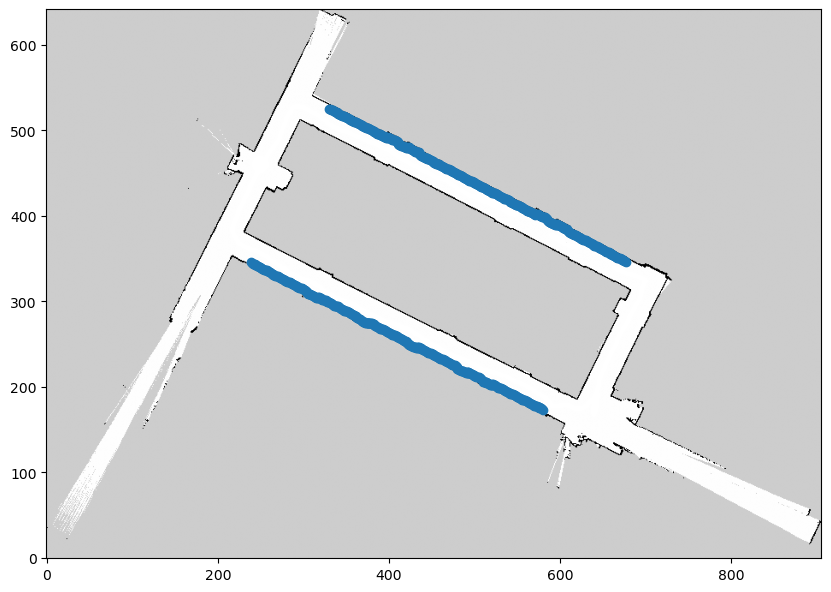

In [39]:
map_img = '/Users/bryanalfaro/Documents/Problem_Sets/ese6500_final/f1tenth_gym/maps/levine_parking/levine.png'
map_img = np.array(Image.open(map_img).transpose(Image.FLIP_TOP_BOTTOM))
parking_1 = np.genfromtxt('/Users/bryanalfaro/Documents/Problem_Sets/ese6500_final/f1tenth_gym/maps/levine_parking/possible_targets_wall1.csv', delimiter=',')
parking_2 = np.genfromtxt('/Users/bryanalfaro/Documents/Problem_Sets/ese6500_final/f1tenth_gym/maps/levine_parking/possible_targets_wall2.csv', delimiter=',')
parking = np.vstack((parking_1, parking_2))
origin = [-31.8, -11.5, 0]
parking_xi, parking_yi = to_img(parking[:, 0], parking[:, 1], origin)
plt.figure(figsize=(10, 10))
plt.imshow(map_img, cmap='gray', origin='lower')
plt.scatter(parking_xi, parking_yi)

In [ ]:
# def local_to_world

def draw_spots(map, target, origin, clearance=0.3):
    '''
    Draws 2 quad spots on map bordered by two obstacles, where the target parking spot in world coordinates
    is given by x_w, y_w, yaw, origin is the origin of the map, and clearnace is the world space distance
    from the target parking spot to the neighboring cars
    '''

    dxs = [-clearance, clearance] # local coordinate x-offset of neighboring cars
    # dxs = [-clearance]
    
    # dimensions of other cars blocking spot
    szx = 0.5
    szy = 0.3
    x, y, yaw = target
    R = np.array([[np.cos(yaw), -np.sin(yaw)],
                  [np.sin(yaw),  np.cos(yaw)]])
    
    for dx in dxs:
        # define coordinates of the spot in local coordinates
        car_pts = np.array([[dx, -szy / 2],
                            [dx, szy / 2],
                            [dx + np.sign(dx) * szx, szy / 2],
                            [dx + np.sign(dx) * szx, -szy / 2]])
        world_pts  = R @ car_pts.T + np.array([[x],[y]])
        world_pts = world_pts.T
        ix, iy = to_img(world_pts[:, 0], world_pts[:, 1], origin)
        img_pts = np.column_stack((ix, iy)).astype(np.int32)
        print(img_pts)
        cv2.drawContours(map, [img_pts], 0, (0, 0, 0), -1)
    return map
        

    


[[499 210]
 [502 215]
 [493 219]
 [490 214]]


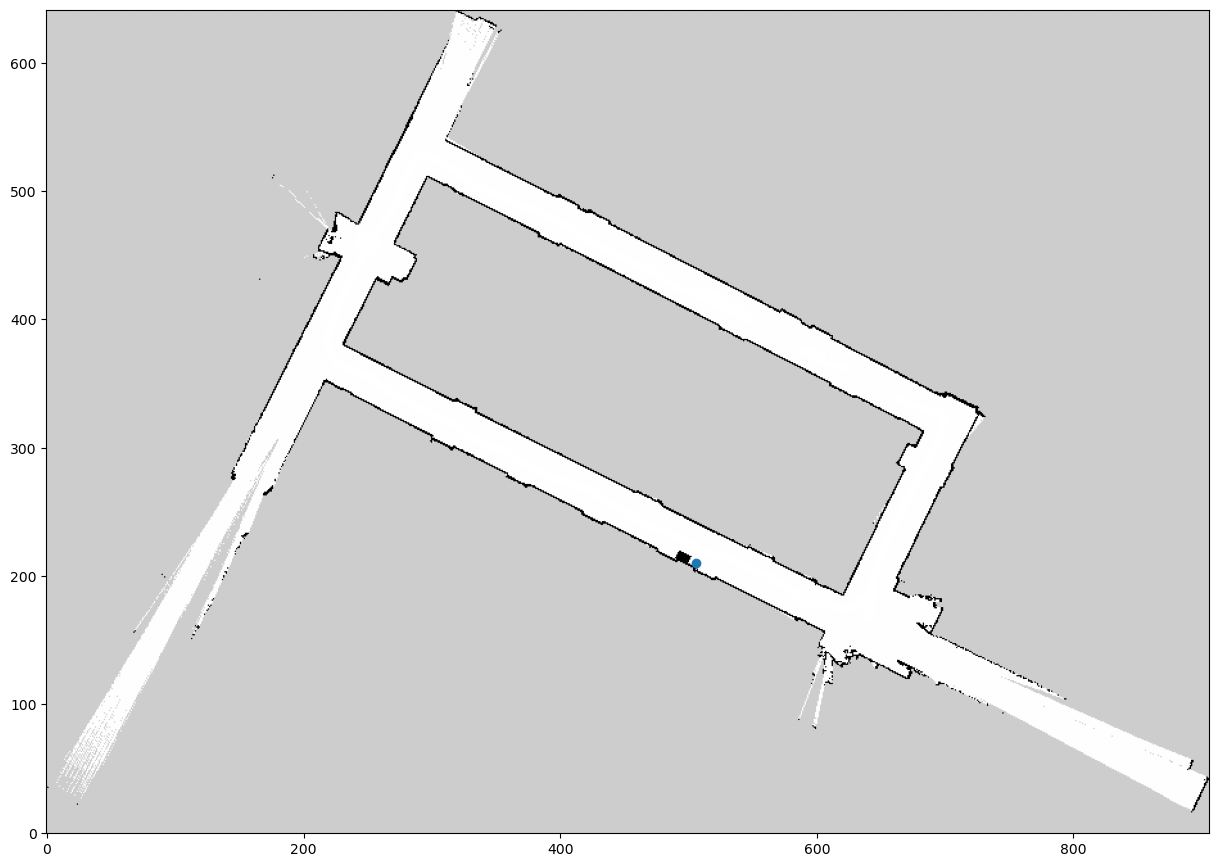

In [61]:
clean_map = np.copy(map_img)
rand_idx = np.arange(parking.shape[0])
rand_idx = np.random.choice(rand_idx)
# print(parking.shape)
rand_spot = parking[rand_idx]
# print(rand_spot)
clean_map = draw_spots(clean_map, rand_spot, origin)
plt.figure(figsize=(15, 15))
plt.imshow(clean_map, cmap='gray', origin='lower')
rx, ry = to_img(rand_spot[0], rand_spot[1], origin)
plt.scatter(rx, ry)

[[  0.8660254    0.5        -91.50635095]
 [ -0.5          0.8660254  158.49364905]]
[[138 243]
 [188 156]
 [361 256]
 [311 343]]


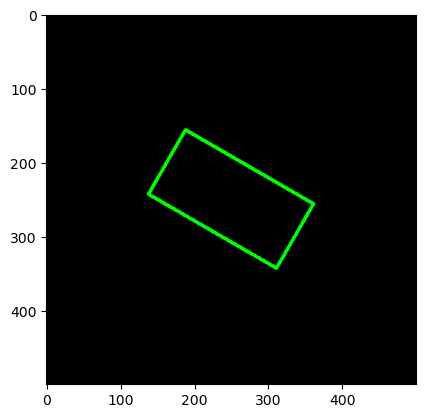

In [21]:
# Create a blank image
img = np.zeros((500, 500, 3), dtype=np.uint8)

# Define the center, size, and angle of rotation for the rectangle
center = (250, 250)
size = (200, 100)
angle = 30

# Get the rotation matrix
matrix = cv2.getRotationMatrix2D(center, angle, 1)
print(matrix)

# Get the corner points of the rectangle
pts = cv2.boxPoints((center, size, angle))

pts = np.intp(pts) # Integer points for drawing
print(pts)
# Draw the rotated rectangle
cv2.drawContours(img, [pts], 0, (0, 255, 0), 3)
plt.imshow(img)

# Display the image
# cv2.imshow('Rotated Rectangle', img)
# cv2.waitKey(0)